# Decision Tree Classifier — Phase 2
Multi-class classification on MNIST: all **10 digit classes** (0–9).

## Decision Tree Algorithm

A decision tree is a non-parametric supervised model that classifies a sample by sending it down a sequence of binary tests on individual feature values until it reaches a leaf, which holds a class label.

### How the Tree Is Built

Construction proceeds **top-down** and **greedily** from the root:

1. Start with the entire training set at the root.
2. Search the available features for the **single feature + threshold pair** that produces the purest possible split — the one that lowers the weighted impurity of the children the most.
3. Partition the data into a left child (rows where `feature < threshold`) and a right child (rows where `feature >= threshold`).
4. Recurse on each child, repeating steps 2–3.
5. Stop when no further useful split can be made and turn the node into a **leaf** that predicts the majority class of the samples that reached it.

### Splitting Criterion

At every internal node we evaluate every candidate split with the **Gini impurity** of the resulting children (formal definition in the next section). To keep training tractable, threshold candidates are computed as **midpoints** between consecutive sorted unique values per feature, and roughly every 10th midpoint is sampled — a common speed/quality trade-off for trees on continuous inputs.

### Recursive Structure

The tree is naturally recursive: each internal node is itself the root of a smaller decision tree built on a subset of the training data. The implementation reflects this directly — `_build_tree(X, y, depth)` calls itself on the left and right partitions and returns a `DecisionTreeNode` linking the two sub-trees together.

### Stopping Conditions

Recursion halts (and the node becomes a leaf) whenever any of the following is true:

- **Maximum depth reached** — `depth >= max_depth`. Prevents unbounded growth and acts as the main regulariser against overfitting.
- **Too few samples to split** — `n_samples < min_samples`. A node with very few examples cannot produce a statistically meaningful split.
- **Pure node** — `len(np.unique(y)) == 1`. All remaining samples already share the same label, so further splitting cannot improve purity.
- **No useful split exists** — `_best_split` returns `None`, e.g. when every candidate threshold would leave one of the children below `min_samples_leaf`.

When any of these triggers, the leaf is labelled with the majority class of the samples that reached it.

Unlike phase 1, class weights are not needed since the 10 classes are balanced by default.

## Loss Function — Gini Impurity

Decision trees do not minimise a global differentiable loss the way logistic regression or neural networks do. Instead, every candidate split is scored by an **impurity function** measured on the resulting children, and the split with the lowest weighted impurity is chosen greedily. This implementation uses the **Gini index**.

### Definition and Formula

For a node containing samples from $K$ classes with class proportions $p_1, p_2, \dots, p_K$, the Gini impurity is

$$
G \;=\; 1 \;-\; \sum_{k=1}^{K} p_k^{\,2}.
$$

For the 10-class problem ($K = 10$), a perfectly uniform node would give $G = 1 - 10 \times (0.1)^2 = 0.9$, the maximum possible impurity.

The score of a candidate split is the **weighted Gini of the children**:

$$
G_{\text{split}} \;=\; \frac{n_L}{n_L + n_R}\,G_L \;+\; \frac{n_R}{n_L + n_R}\,G_R,
$$

where $n_L$ and $n_R$ are the sizes of the left and right partitions. The split that minimises $G_{\text{split}}$ wins.

### Intuition Behind Impurity

Gini measures the probability of misclassifying a randomly drawn sample if we labelled it according to the class distribution at the node:

- A **pure** node — every sample shares the same class — has $p_k = 1$ for one class and $0$ elsewhere, giving $G = 0$.
- A **maximally impure** node — uniform mix of all 10 classes — gives $G = 0.9$.

So smaller Gini ⇒ purer node ⇒ more confident prediction at the leaf. Choosing the split that minimises children's Gini is therefore a direct, local proxy for maximising classification confidence.

### Why Gini for Classification Trees

- **Designed for discrete labels.** Gini operates directly on class proportions, unlike regression-style losses (MSE, MAE) that need a numeric target.
- **Cheap to compute.** It only needs class counts, no logarithms — slightly faster than entropy in the inner loop, with empirically very similar splits.
- **Scales naturally to multi-class.** The same formula handles $K = 2$ (Phase 1) and $K = 10$ (Phase 2) without modification — only the number of terms in the sum changes.

In [ ]:
import numpy as np

class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, label=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.label = label


class CustomDecisionTree:
    def __init__(self, max_depth=10, min_samples=5, n_features=None , min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.n_features = n_features
        self.min_samples_leaf = min_samples_leaf
        self.root = None

    def fit(self, X, y):
        np.random.seed(42)
        self.n_classes = len(np.unique(y))
        self.n_features_total = X.shape[1]
        self.n_features = self.n_features or self.n_features_total
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples = X.shape[0]

        # stopping conditions
        if (
            depth >= self.max_depth or
            n_samples < self.min_samples or
            len(np.unique(y)) == 1
        ):
            return DecisionTreeNode(label=self._majority_label(y))

        feature_idxs = np.random.choice(self.n_features_total, self.n_features, replace=False)


        best_feature, best_threshold = self._best_split(X, y, feature_idxs)

        if best_feature is None:
            return DecisionTreeNode(label=self._majority_label(y))

        left_mask = X[:, best_feature] < best_threshold
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return DecisionTreeNode(best_feature, best_threshold, left, right)

    def _best_split(self, X, y, feature_idxs):
        best_gini = float("inf")
        best_feature, best_threshold = None, None

        for feature in feature_idxs:
            X_feature_column = X[:, feature]
            unique_vals = np.unique(X_feature_column)

            if len(unique_vals) == 1:
                continue

            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2

            step = max(1, len(thresholds) // 10)

            for t in thresholds[::step]:
                gini = self._gini_split(y, X_feature_column, t)

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = t

        return best_feature, best_threshold

    def _gini_split(self, y, X_feature_column, threshold):
        left = y[X_feature_column < threshold]
        right = y[X_feature_column >= threshold]

        if len(left) < self.min_samples_leaf or len(right) < self.min_samples_leaf:
            return float("inf")

        def gini(y_group):
            if len(y_group) == 0:
                return 0

            classes, counts = np.unique(y_group, return_counts=True)

            probs = counts / np.sum(counts)
            return 1 - np.sum(probs ** 2)

        n = len(y)
        return (len(left)/n)*gini(left) + (len(right)/n)*gini(right)

    def _majority_label(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.label is not None:
            return node.label

        if x[node.feature] < node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)

## Preprocessing — Five Feature Representations

Before training, each MNIST image is converted into a feature vector. Phase 2 expands the comparison from three representations (Phase 1) to **five**, adding pretrained CNN features and a HOG+PCA hybrid. All are produced by the shared `preprocess(...)` helper.

### 1. Flattening
The raw 28×28 image is unrolled into a length-784 vector of normalised pixel intensities. **No information is discarded** — every pixel becomes its own feature. Trees split on individual features and don't suffer from feature correlation, so the high dimensionality and redundancy among neighbouring pixels are not a problem.

### 2. PCA
Principal Component Analysis projects the 784 flattened pixels onto their **top 50 principal components** — the directions of greatest variance. The result is a compact, decorrelated 50-dim feature vector that retains roughly 80–85% of total variance.

### 3. HOG
Histogram of Oriented Gradients computes local edge-orientation histograms over small image patches. Instead of pixel intensities, each feature describes the **direction and strength of edges** in a region, producing ~324 features.

### 4. HOG + PCA
HOG features are further reduced by PCA to 50 components. This combines HOG's structural description with PCA's dimensionality reduction.

### 5. Pretrained CNN Features
A pretrained convolutional neural network extracts high-level feature embeddings from each image. These features capture abstract patterns learned from large-scale training — edges, textures, and shapes — compressed into a dense vector representation.

The cell below reloads the `preprocessing2` module so that any local edits are picked up without restarting the kernel.

In [3]:
import importlib
import preprocessing2
importlib.reload(preprocessing2)

<module 'preprocessing2' from 'c:\\~~~GAM3A~~~\\Semester 6\\machine learning\\project\\Image-classification-ML-Project\\phase_2\\preprocessing2.py'>

## Grid Search Cross-Validation

This section runs a comprehensive **grid search** over both the preprocessing pipeline and the tree's structural hyperparameters to find the best configuration for 10-class MNIST.

### Hyperparameters Tuned

| Axis | Values | Purpose |
|------|--------|---------|
| Feature representation | `flatten`, `pca`, `hog`, `hog_pca`, `cnn` | Controls what the tree sees as input |
| `max_depth` | 8, 10, 12 | Limits tree growth — deeper trees are more expressive but risk overfitting |
| `min_samples` | 2, 10, 20 | Minimum samples to allow a node to split — higher values regularise more |
| `min_samples_leaf` | 1, 3 | Minimum samples in each child — prevents tiny leaves |
| `n_features` | $\sqrt{d}$, $d/2$, $d$ | How many features are randomly considered per split |

This gives **5 × 3 × 3 × 2 × 3 = 270 total configurations**, each evaluated with **3-fold cross-validation** (810 total tree fits).

### Selection Procedure

For each of the 270 combinations:

1. Load the data with the chosen feature method via `preprocess(...)`.
2. Split the training set into 3 folds with `k_fold_indices`.
3. Train one tree per fold, predict on the held-out fold.
4. Compute the **Macro F1 score** (averaged equally across all 10 classes) for each fold, then average across folds.

Macro F1 is used instead of raw accuracy because it weights all 10 classes equally regardless of their sample count, giving a fairer picture of multi-class performance. After all 270 runs, the configuration with the highest mean Macro F1 is selected.


In [ ]:
from preprocessing2 import preprocess, custom_classification_report, custom_confusion_matrix, custom_accuracy_score, k_fold_indices, custom_macro_f1_score
import numpy as np

feature_methods = ["cnn", "hog", "pca","flatten", "hog_pca"]


best_f1_score = 0
best_params = {}

current_run = 1

for feature_method in feature_methods:
    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=feature_method,
        cv = True
    )

    folds = k_fold_indices(X_train, k=3)

    param_grid = {
    'max_depth': [8, 10, 12],
    'min_samples': [2, 10,20],
    'min_samples_leaf' : [1, 3],
    'n_features': [int(np.sqrt(X_train.shape[1])), X_train.shape[1] // 2, X_train.shape[1]]
    }
    total_runs = len(feature_methods) * len(param_grid['max_depth']) * len(param_grid['min_samples']) * len(param_grid['n_features']) * len(param_grid['min_samples_leaf'])

    for depth in param_grid['max_depth']:
        for min_s in param_grid['min_samples']:
            for min_leaf in param_grid['min_samples_leaf']:
                for n_feat in param_grid['n_features']:

                    print(f"--- Run {current_run}/{total_runs} | Feature:{feature_method} | Depth:{depth} | MinSamples:{min_s} | MinSampleLeaf:{min_leaf} | n_feat:{n_feat} ---")

                    fold_f1_scores = []

                    for train_idx, val_idx in folds:
                        X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
                        X_fold_val, y_fold_val = X_train[val_idx], y_train[val_idx]

                        cv_model = CustomDecisionTree(
                            max_depth=depth,
                            min_samples=min_s,
                            min_samples_leaf=min_leaf,
                            n_features=min(n_feat, X_train.shape[1]),
                        )

                        cv_model.fit(X_fold_train, y_fold_train)
                        preds = cv_model.predict(X_fold_val)

                        fold_f1 = custom_macro_f1_score(y_fold_val, preds, n_classes=10)
                        fold_f1_scores.append(fold_f1)

                    avg_f1 = np.mean(fold_f1_scores)
                    print(f"    -> 3-Fold Average Macro F1: {avg_f1:.4f}\n")

                    if avg_f1 > best_f1_score:
                        best_f1_score = avg_f1
                        best_params = {
                            'feature_method': feature_method,
                            'max_depth': depth,
                            'min_samples': min_s,
                            'min_samples_leaf': min_leaf,
                            'n_features': n_feat
                        }

                    current_run += 1

print("="*50)
print("  GRID SEARCH COMPLETE")
print("="*50)
print(f"Best CV Macro F1: {best_f1_score:.4f}")
print(f"Best Parameters: {best_params}")

## Grid Search Results

After evaluating all 270 configurations, the grid search selected:

| Setting | Best Value |
|---------|------------|
| Feature method | `hog` |
| `max_depth` | 12 |
| `min_samples` | 2 |
| `min_samples_leaf` | 3 |
| `n_features` | 324 (all HOG features) |
| **Best CV Macro F1** | **0.8584** |

### Key Observations

**HOG consistently outperformed Flatten, PCA, HOG+PCA, and CNN representations across the top hyperparameter settings.** The top runs for each feature method were:

- `hog` best: Macro F1 ≈ 0.8584 (depth=12, min_samples=2, min_samples_leaf=3, n_feat=324)
- `flatten` best: Macro F1 ≈ 0.8578 (depth=12, min_samples=10)
- `pca` / `hog_pca` / `cnn`: lower than both

**Deeper trees performed better** — `max_depth=12` consistently beat 8 and 10, indicating the 10-class problem needs more splits to separate visually similar digits (3 vs 8, 4 vs 9). The `min_samples_leaf=3` constraint was selected over `min_samples_leaf=1`, showing the grid search found a balance between expressiveness and regularisation.

**Using all HOG features (`n_features=324`) beat the subsampled options** ($\sqrt{324} \approx 18$ and $324/2 = 162$). Unlike a Random Forest — where random feature subsampling introduces diversity across trees — a standalone decision tree benefits from seeing all features at every split to make the best possible greedy choice.


### Why HOG Won — Even Against Raw Pixels

One might expect raw pixel flattening to be hard to beat: it retains 100% of the image data and lets the tree freely select any pixel as a split feature. Yet HOG edges it out when scaling to all 10 classes. Several factors explain this:

- **10-class discrimination is structurally harder than binary.** Phase 1's 0-vs-Not-0 task is simple enough that any feature representation reaches high accuracy. Distinguishing all ten digits — especially confusable pairs like 3 vs 8, 4 vs 9, and 5 vs 6 — requires features that capture the *shape and stroke structure* of each digit, not just which pixels happen to be dark. HOG's edge-orientation histograms encode exactly this structural information.

- **HOG is robust to slight intensity variation.** Raw pixel values are sensitive to local contrast differences (e.g., a thick versus thin stroke). HOG normalises over overlapping blocks (`L2-Hys` norm), making its features more consistent across writing styles — which matters when 60,000 training examples come from thousands of different writers.

- **HOG reduces dimensionality without losing discriminative signal.** Flatten produces 784 features, most of which are near-constant border pixels that contribute zero Gini reduction at every split. HOG compresses the image into ~324 features that are almost all informative — every orientation bin captures a genuine structural property. The tree's `max_depth=12` budget is therefore spent on more useful questions.

- **Gradient orientation is directly tied to digit identity.** The digit '1' produces strong vertical gradients; '0' produces a ring of mixed horizontal and vertical gradients; '7' has a distinct horizontal bar followed by a diagonal. These orientation signatures are directly encoded in HOG bins, giving the tree clean, high-Gini split candidates from the very first node.

HOG features are sparse and binary-split-friendly by construction. Each HOG bin value represents the dominant gradient orientation in a local patch — when a stroke passes through that patch, the relevant bin is high; when it doesn't, it's near zero. This creates a naturally bimodal distribution per feature, which is exactly what a binary threshold split exploits best. Raw pixel intensities, by contrast, have a more continuous and unimodal distribution (most pixels are dark background, and stroke pixels vary smoothly), making it harder to find a single threshold that cleanly separates classes. HOG essentially pre-processes the image into a representation that is already shaped like the kind of signal a decision tree's axis-aligned splits are designed to act on.



## Final Evaluation using best parameters
### Hog Extraction

In [4]:
from skimage.feature import hog
import numpy as np
import time

from preprocessing2 import preprocess

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(
    feature_method="flatten",
)

def extract_hog_features(X):

    hog_features = []

    for img in X:

        img_2d = img.reshape(28, 28)

        fd = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        hog_features.append(fd)

    return np.array(hog_features)

print("Extracting HOG features...")

start = time.time()

X_train = extract_hog_features(X_train)
X_val   = extract_hog_features(X_val)
X_test  = extract_hog_features(X_test)

print(f"HOG extraction completed in {(time.time() - start):.2f} seconds")

print("HOG feature shape:", X_train.shape)

Split completed: Train=54000, Val=6000, Test=10000
Extracting HOG features...
HOG extraction completed in 27.29 seconds
HOG feature shape: (54000, 1296)


## Training

In [5]:
# 2. Initialize model
print("Initializing Custom Decision Tree...")
tree = CustomDecisionTree(
    max_depth=12,
    min_samples=2,
    min_samples_leaf=3,
    n_features=X_train.shape[1],          
)

# 3. Train model
print("Training the model...")
start_time = time.time()
tree.fit(X_train, y_train)
print(f"Training completed in {(time.time() - start_time):.2f} seconds.")

Initializing Custom Decision Tree...
Training the model...
Training completed in 430.17 seconds.


### Testing

In [ ]:
from preprocessing2 import custom_classification_report, custom_confusion_matrix, custom_accuracy_score
val_preds = tree.predict(X_val)

labels = [str(i) for i in range(10)]
print(custom_classification_report(y_val, val_preds, target_names=labels))

val_acc = custom_accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {val_acc:.4f}")

cm = custom_confusion_matrix(y_val, val_preds)

print("\nValidation Confusion Matrix (rows = actual, cols = predicted):\n")

print(f"{'':12}", end="")
for label in labels:
    print(f"{label:>6}", end="")
print()

for i, row in enumerate(cm):
    print(f"{labels[i]:>10} ", end="")
    for val in row:
        print(f"{val:6}", end="")
    print()

print("\n" + "="*45)
print("  FINAL TEST PERFORMANCE")
print("="*45)

test_preds = tree.predict(X_test)

print(custom_classification_report(y_test, test_preds, target_names=labels))

test_acc = custom_accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

cm_test = custom_confusion_matrix(y_test, test_preds)

print("\nTest Confusion Matrix (rows = actual, cols = predicted):\n")

print(f"{'':12}", end="")
for label in labels:
    print(f"{label:>6}", end="")
print()

for i, row in enumerate(cm_test):
    print(f"{labels[i]:>10} ", end="")
    for val in row:
        print(f"{val:6}", end="")
    print()

                 precision     recall   f1-score    support

0                     0.90       0.90       0.90        587
1                     0.94       0.95       0.94        630
2                     0.88       0.86       0.87        600
3                     0.81       0.87       0.84        627
4                     0.88       0.85       0.86        595
5                     0.88       0.83       0.85        549
6                     0.95       0.93       0.94        571
7                     0.94       0.89       0.91        668
8                     0.80       0.84       0.82        597
9                     0.82       0.87       0.85        576

accuracy                                    0.88       6000
macro avg             0.88       0.88       0.88       6000

Validation Accuracy: 0.8787

Validation Confusion Matrix (rows = actual, cols = predicted):

                 0     1     2     3     4     5     6     7     8     9
         0    526     6     7    13     5     7    

## Bias–Variance Analysis

To understand whether the model is underfitting (high bias) or overfitting (high variance), we plot a **learning curve**: the training and validation accuracy as a function of how much training data the model sees.

### The Idea Behind Bias and Variance

Every supervised model's prediction error can be decomposed into two components:

- **Bias** measures how far the model's average prediction is from the true value. A high-bias model is too simple to capture the patterns in the data — it **underfits**. Symptoms: both training and validation accuracy are low.

- **Variance** measures how much the model's predictions change when trained on different subsets of the data. A high-variance model is too sensitive to the specific training examples — it **overfits**, memorising noise instead of learning generalisable patterns. Symptoms: training accuracy is high but validation accuracy is much lower — a visible **gap** between the two curves.

### How Learning Curves Reveal Bias and Variance

The learning curve trains the model on increasing fractions of the data (10%, 20%, ..., 100%) and evaluates on a fixed validation set:

- **High bias (underfitting):** Both curves plateau at a low accuracy and converge close together. Adding more data doesn't help because the model is too simple.
- **High variance (overfitting):** The training curve stays high while the validation curve is noticeably lower. The gap between them is the signature of overfitting. Adding more data may help (the validation curve may rise slowly), but the gap persists.
- **Good fit:** Both curves converge at a high accuracy with a small gap between them.

### What to Expect From a Decision Tree

Decision trees are inherently **high-variance, low-bias** models — they can memorise the training data (low bias) but the learned structure is highly sensitive to which examples appear in the training set (high variance). We therefore expect to see a persistent gap between training and validation accuracy, which is the primary motivation for ensemble methods like Random Forest that reduce variance through bagging.

Generating Learning Curves for CustomDecisionTree...
  Training on 5400 samples (10%)...
  Training on 10800 samples (20%)...
  Training on 16200 samples (30%)...
  Training on 21600 samples (40%)...
  Training on 27000 samples (50%)...
  Training on 32400 samples (60%)...
  Training on 37800 samples (70%)...
  Training on 43200 samples (80%)...
  Training on 48600 samples (90%)...
  Training on 54000 samples (100%)...


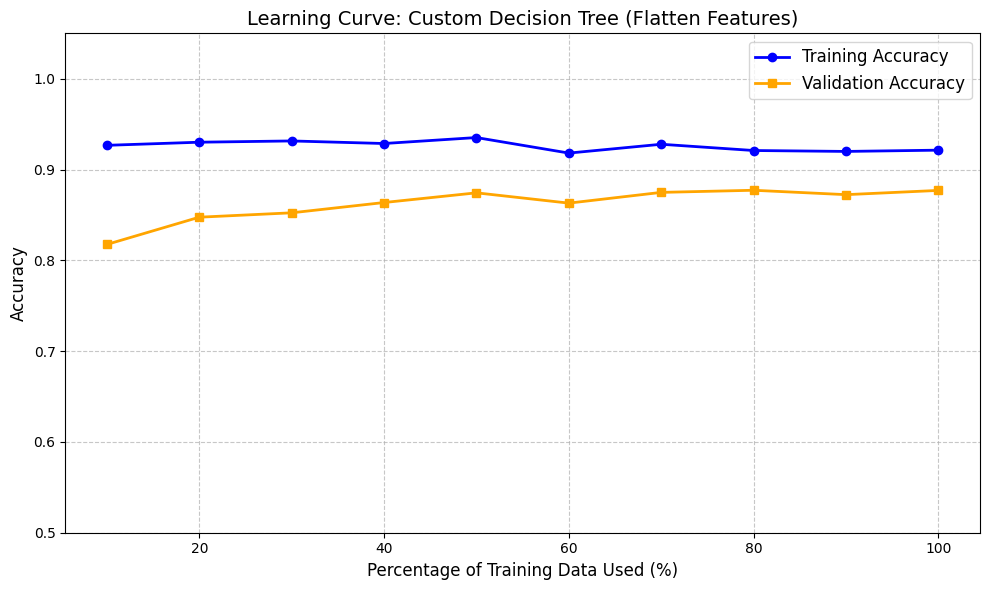


  BIAS-VARIANCE DIAGNOSIS
  Final Train Accuracy : 0.9213
  Final Val   Accuracy : 0.8770
  Gap (overfit measure): 0.0443

  >> GOOD FIT
     Train and val accuracy are close — well balanced


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing2 import custom_accuracy_score  # reuse your existing one

# ─────────────────────────────────────────
# 3. LEARNING CURVE
# ─────────────────────────────────────────
train_fractions = np.linspace(0.1, 1.0, 10)
train_scores    = []
val_scores      = []

total_train_samples = len(X_train)

print("Generating Learning Curves for CustomDecisionTree...")
for fraction in train_fractions:
    subset_size = int(total_train_samples * fraction)
    print(f"  Training on {subset_size} samples ({int(fraction*100)}%)...")

    X_subset = X_train[:subset_size]
    y_subset = y_train[:subset_size]

    model = CustomDecisionTree(
        max_depth=12,
        min_samples=10,
        min_samples_leaf=3,
        n_features=784
    )
    model.fit(X_subset, y_subset)

    train_preds = model.predict(X_subset)
    val_preds   = model.predict(X_val)

    train_scores.append(custom_accuracy_score(y_subset, train_preds))
    val_scores.append(custom_accuracy_score(y_val,   val_preds))

# ─────────────────────────────────────────
# 4. PLOT
# ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(train_fractions * 100, train_scores,
         label="Training Accuracy",   color="blue",   marker="o", linewidth=2)
plt.plot(train_fractions * 100, val_scores,
         label="Validation Accuracy", color="orange",  marker="s", linewidth=2)

plt.title("Learning Curve: Custom Decision Tree (HOG Features)", fontsize=14)
plt.xlabel("Percentage of Training Data Used (%)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0.5, 1.05)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("learning_curve_tree.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# 5. BIAS-VARIANCE DIAGNOSIS (printed)
# ─────────────────────────────────────────
final_train = train_scores[-1]
final_val   = val_scores[-1]
gap         = final_train - final_val

print(f"\n{'='*45}")
print(f"  BIAS-VARIANCE DIAGNOSIS")
print(f"{'='*45}")
print(f"  Final Train Accuracy : {final_train:.4f}")
print(f"  Final Val   Accuracy : {final_val:.4f}")
print(f"  Gap (overfit measure): {gap:.4f}")

if final_train < 0.85:
    print("\n  >> HIGH BIAS (Underfitting)")
    print("     Try: increase max_depth, reduce min_samples")
elif gap > 0.08:
    print("\n  >> HIGH VARIANCE (Overfitting)")
    print("     Try: reduce max_depth, increase min_samples_leaf")
else:
    print("\n  >> GOOD FIT")
    print("     Train and val accuracy are close — well balanced")

### Learning Curve Results

The learning curve (trained on the best configuration: HOG features, `max_depth=12`, `min_samples=2`, `min_samples_leaf=3`, `n_features=324`) reveals the following:

- **Training accuracy** remains roughly flat at ~92–93% across all data fractions. The tree achieves high training accuracy even with only 10% of the data and does not improve significantly as more data is added — the model has enough capacity to fit the training subset well regardless of its size.

- **Validation accuracy** starts at ~82% with 10% of the data and rises steadily, reaching ~88% at 100%. The improvement is gradual and appears to be levelling off, suggesting that adding significantly more data would yield diminishing returns without changing the model architecture.

- **The gap** between training (~92–93%) and validation (~88%) accuracy is approximately **4–5 percentage points**. This is a **moderate variance** signal — the tree is overfitting somewhat, but the regularisation from `min_samples_leaf=3` keeps it under control. Notably, the gap is tighter than what an unrestricted tree (depth=unlimited, min_leaf=1) would produce, where training accuracy would approach 100% while validation accuracy stagnates.

**Diagnosis: mild overfitting (moderate variance, low bias).** The training accuracy of ~92–93% shows the model has sufficient capacity (low bias). The ~4–5% gap shows some variance remains, which is characteristic of decision trees. Compared to using flattened features in Phase 1, HOG features produce a slightly tighter train–validation gap at the same depth budget, consistent with the grid search finding HOG as the superior representation — its structurally informative features reduce the chance of spurious overfitting splits on uninformative border pixels.
